# Cluster LOCO-Split 

Cluster LOCO-Split estimates the finite-calibration-sample population target
$$\Delta_{j}(\mathcal{D}_{tr};\hat f_{tr}, \hat f_{tr}^{-j})=\mathbb E_{X \sim P_{X^n}}\left[\operatorname{Error}\big(C(X),\hat f^{-j}_{tr}(X_{-j})\big)-\operatorname{Error}\big(C(X),\hat f_{tr}(X)\big)\mid \mathcal{D}_{tr},\hat f_{tr}, \hat f_{tr}^{-j}\right],$$
where $\mathcal{D}_{tr}=(X_{tr},C(X_{tr}))$, $\hat f_{tr}, \ \hat f_{tr}^{-j}$ contains the fitted full and reduced classifiers, and $X \sim P_{X^n}$ is independent of training. Training labels and classifiers are held fixed; the expectation includes fresh calibration data and calibration-clustering randomness. The calibration size $n$ is part of the target.

Here `Error` is mean hinge error after Hungarian alignment **separately for each classifier**, matching the package's alignment convention. Both losses use the same calibration partition, but may use different label permutations. The alignment maximizes hard-label agreement, not necessarily probability-based hinge agreement, and is included in the expectation.


In [4]:
import sys
from pathlib import Path
sys.path.append("../../")
from simulations.toy_datasets import generate_data
import numpy as np
np.random.seed(6)
X, y = generate_data(n_samples=1000)
# add 1 noise feature
X = np.concatenate([X, np.random.normal(size=(X.shape[0],1))], axis=1)
print(X.shape)

(1000, 3)


In [5]:
from sklearn.model_selection import train_test_split
X_tr, X_cal, y_tr, y_cal = train_test_split(X, y, test_size=0.5)
np.random.seed(10)
X_test, y_test = generate_data(n_samples=1000)
X_test = np.concatenate([X_test, np.random.normal(size=(X_test.shape[0],1))], axis=1)

In [6]:
from clim.utils import hinge_error
from clim.utils.utils import label_alignment
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

K = 3
model = KMeans(n_clusters=K, n_init=10, random_state=6)
z_tr = model.fit_predict(X_tr)
# Fit once, using the same training labels for every classifier.
clf = RandomForestClassifier(random_state=0)
clf.fit(X_tr, z_tr)
clfs_loco = []
for j in range(X_tr.shape[1]):
    clf_j = RandomForestClassifier(random_state=0)
    clf_j.fit(np.delete(X_tr, j, axis=1), z_tr)
    clfs_loco.append(clf_j)
for fitted_clf in [clf, *clfs_loco]:
    np.testing.assert_array_equal(fitted_clf.classes_, np.arange(K))


def score_calibration(X_ca, seed):
    # Cluster once per sample; do not refit the training models.
    z_ca = KMeans(n_clusters=K, n_init=10, random_state=seed).fit_predict(X_ca)
    mapping = label_alignment(clf.predict(X_ca), z_ca, K)
    errors = hinge_error(mapping[z_ca], clf.predict_proba(X_ca))
    differences = []
    for j, clf_j in enumerate(clfs_loco):
        X_ca_j = np.delete(X_ca, j, axis=1)
        mapping_j = label_alignment(clf_j.predict(X_ca_j), z_ca, K)
        errors_j = hinge_error(mapping_j[z_ca], clf_j.predict_proba(X_ca_j))
        differences.append(errors_j - errors)
    differences = np.column_stack(differences)
    # Second output is pointwise SD, NOT the SE of the split score.
    return differences.mean(axis=0), differences.std(axis=0, ddof=1)


# Local scoring implements the shared-partition definition above; the package
# helper currently refits training/calibration clusterings inside its feature loop.
res = score_calibration(X_cal, seed=10)

In [7]:
res[0], res[1]  # observed score, pointwise loss-difference SD (not SE)

(array([ 0.29058,  0.10636, -0.04106]),
 array([0.27897871, 0.25104102, 0.08757863]))

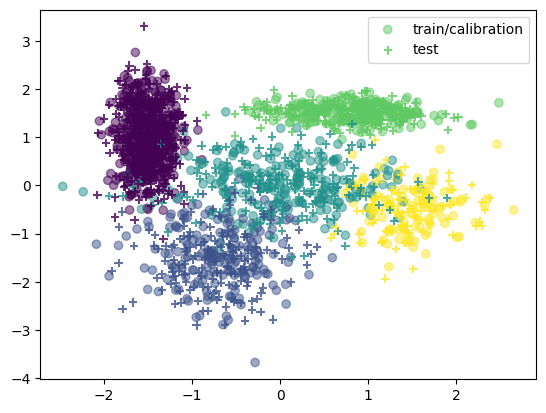

In [8]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:, 1],c=y, marker='o', alpha=0.5, label='train/calibration')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='+', alpha=0.8, label='test')
plt.legend()

In [ ]:
n_test = len(X_cal)  # Match the calibration size of the observed score.
def compute_target(seed, n_test):
    # Separate data-generation and calibration-clustering randomness.
    data_seed, cluster_seed = np.random.SeedSequence(int(seed)).spawn(2)
    state = np.random.get_state()
    try:
        np.random.seed(int(data_seed.generate_state(1)[0]))
        X_test, _ = generate_data(n_test)
        X_test = np.concatenate([X_test, np.random.normal(size=(X_test.shape[0],1))], axis=1)
        
    finally:
        np.random.set_state(state)
    return score_calibration(X_test, seed=int(cluster_seed.generate_state(1)[0]))

In [ ]:
from joblib import Parallel, delayed
B = 10000  # Reduce for a quick run; increase until MC SE is sufficiently small.
seeds = np.random.default_rng(42).choice(2**32, size=B, replace=False)
# Processes isolate generate_data's legacy global RNG; fitted models stay fixed.
results_pop = Parallel(n_jobs=-1, backend='loky', verbose=10)(delayed(compute_target)(seed, n_test) for seed in seeds)

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
#boxplot
p = X.shape[1]
Deltas_pop = np.array(results_pop)
Delta = np.mean(Deltas_pop[:, 0, :], axis=0)
fig = plt.figure(figsize=(15, 4))
gs = fig.add_gridspec(1, 4,  width_ratios=[1, 2, 2, 2])
ax = [fig.add_subplot(gs[i]) for i in range(p+1)]
ax[0].boxplot([Deltas_pop[:, 0, j] for j in range(p)], tick_labels=[f'{i+1}' for i in range(p)], showmeans=True, showfliers=False, label=r'$\Delta_j^{MC} \approx \Delta_j(\mathcal{D}_{tr})$')
ax[0].set_ylabel(r'Feature importance')
ax[0].set_xlabel('Feature')
ax[0].scatter(np.arange(1, p+1), res[0], color='b', linestyle='dashed', linewidth=1, label=r'Point estimate $\hat \Delta_j$')
#ax[0].set_ylim((0.0, 0.45))


for j in range(p):
    ax[j+1].hist(Deltas_pop[:,0,j], color='gray', bins=100, density=True, alpha=0.2)
#     plt.axvspan(*split_interval[:, j], color='gray', alpha=0.12,
#                 label='Central 95% of fresh split scores')
    ax[j+1].axvline(Delta[j], color='r', linestyle='dashed', linewidth=1,
                label=rf'MC estimates for feature {j}')
    ax[j+1].axvline(res[0][j], color='b', linestyle='-', linewidth=1,
                label=rf'Observed $\hat\Delta_{{{j+1}}}$')
    ax[j+1].set_xlabel(f'Feature {j+1}')

handles = [Patch(facecolor='gray', alpha=0.2, edgecolor='none', label='Monte Carlo distribution'),
    Line2D([], [], color='g', linestyle='', marker='^', label=r'MC target approximation $\Delta_{j}^{MC}$'),
    Line2D([], [], color='b', linestyle='-', marker='o', label=r'Cluster LOCO-Split estimate $\hat{\Delta}_j$')]

fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=3, frameon=False, fontsize=10)
fig.subplots_adjust(bottom=0.22, wspace=0.35)
fig.savefig('../figures/supp8_cluster_loco_split_target.pdf')


# Cluster LOCO-MP: finite-sample population target

Let $D_N=(X_1,\ldots,X_N)\sim P_X^N$, and let $U$ contain minipatch and model randomness. Patch $b$ selects observations $I_b$ and features $F_b$ and fits a probability classifier $\hat p_b$ to its cluster labels, aligned to the full-data reference $z(D_N,U)$. Define
$$\hat p_{-i}(x)=\frac{\sum_{b:i\notin I_b}\hat p_b(x_{F_b})}{\#\{b:i\notin I_b\}},\qquad
\hat p_{-i,-j}(x)=\frac{\sum_{b:i\notin I_b,\,j\notin F_b}\hat p_b(x_{F_b})}{\#\{b:i\notin I_b,\,j\notin F_b\}}.$$
With $V_j$ the observations having both predictions, the implemented score is
$$\hat\Delta_j^{MP}(D_N,U)=\frac1{|V_j|}\sum_{i\in V_j}\left[\ell\{z_i,\hat p_{-i,-j}(X_i)\}-\ell\{z_i,\hat p_{-i}(X_i)\}\right].$$
The corresponding procedure-level population target is
$$\boxed{\Delta^{MP}_{j,N,B_{MP}}(P_X)=\mathbb E_{D_N,U}[\hat\Delta_j^{MP}(D_N,U)].}$$
Patch sizes, base models, preprocessing and reference construction are fixed settings. Unlike the conditional Split target, this expectation averages over **fresh datasets and complete MP fits**. Excluding a feature changes which patch clusterings and classifiers contribute. The full-data reference includes the scored observations; this is an exact expectation of the implemented statistic, not a claim of unbiased estimation of an independent-test-point risk.

Use `B_mp` for patches per fit and `R_mc` for independent Monte Carlo repetitions. For scores $d_{rj}$, estimate the target by their mean and its Monte Carlo SE by $\operatorname{sd}(d_{rj})/\sqrt{R_{mc}}$. Do not use the package's within-fit `delta_se` as this Monte Carlo SE. The code checks prediction coverage and stops on an undefined score rather than silently dropping or resampling runs. If any $V_j$ is empty, the statistic is undefined; a larger fixed patch budget or an explicit missing-score convention is needed before defining its unconditional expectation.

In [28]:
import sys
sys.path.append('../../')
from simulations.simulators import BaseSimulator, GenerateCovariances
# noise_plan: list of dicts like:
#   [{"type":"gaussian","d":10},
#    {"type":"student-t","d":10,"df":10},
#    {"type":"triangular","d":10,"low":-1,"high":1},
#    {"type":"laplace","d":10,"scale":1.0}]
noise_plan = [{'type':'gaussian', 'd':190}]
K = 5
n_per_cluster=100

def generate_new_data(n_per_cluster, random_state=42):
    # Adds correlation in signal
    Cov_k = [GenerateCovariances(dim=10, covMethod='onion', eta=1/(k+1)).covGen()[0] for k in range(K)]

    sim = BaseSimulator(K=K, n_samples_per_cluster=n_per_cluster, alpha=1.5, d_0=10, method='gaussian', random_state=random_state)
    X, y = sim.generate_data()
    # sequentially append noise blocks
    for block in noise_plan:
        nt = block["type"]
        d = int(block["d"])
        kw = {k: v for k, v in block.items() if k not in ("type", "d")}
        sim.add_noise(noise_d=d, noise_type=nt, random_state=random_state)
    X_aug = sim.X
    return X_aug, y

X_aug, y = generate_new_data(n_per_cluster)

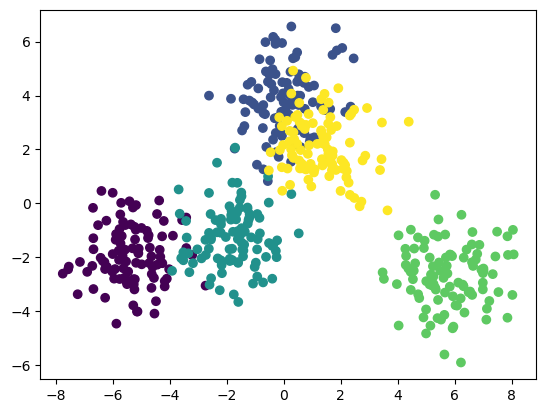

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_aug)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)

In [29]:
from clim import ClusterLOCOMP
from clim.utils import hinge_error
from sklearn.tree import DecisionTreeClassifier
from joblib import Parallel, delayed
from contextlib import redirect_stderr
from io import StringIO
import numpy as np
from sklearn.cluster import KMeans

# These settings define the MP target. Change them in both observed and MC fits.
N_mp, p_mp = X_aug.shape
K_mp = K
B_mp = 5000
R_mc = 200  # Increase for greater MC precision; separate from B_mp.
patch_n_mp = max(K_mp, int(0.2 * N_mp))
patch_m_mp = min(p_mp - 1, max(1, int(np.ceil(0.5 * p_mp))))
if not (K_mp <= patch_n_mp < N_mp and 1 <= patch_m_mp < p_mp):
    raise ValueError("Patches must leave out observations and features")

def fit_score_mp(X_data, seed, B_mp, patch_n, patch_m, K):
    g = ClusterLOCOMP(K=K, B=B_mp, random_state=int(seed),
        base_clusterer=KMeans(n_clusters=K, n_init=10), base_classifier=DecisionTreeClassifier())
    g.fit(X_data, patch_n=patch_n, patch_m=patch_m,
          reference='full', standardize=False, parallel_MP=False, pprint=False)
    # Suppress the per-feature progress bar; exceptions still propagate.
    with redirect_stderr(StringIO()):
        out = g.score(error_metric=hinge_error, agg='mean', parallel_features=False)
    if not np.all(np.isfinite(out['delta'])) or np.any(out['n_eff'] == 0):
        raise RuntimeError("Undefined MP score: increase the fixed B_mp budget and rerun")
    return np.asarray(out['delta']), np.asarray(out['n_eff'])


def compute_mp_target(seed, N, p, B_mp, patch_n, patch_m, K):
    data_seed, fit_seed = np.random.SeedSequence(int(seed)).spawn(2)
    state = np.random.get_state()
    n_per_cluster = int(N/K)
    try:
        np.random.seed(int(data_seed.generate_state(1)[0]))
        X_mc, _ = generate_new_data(n_per_cluster)
        noise_d = p - X_mc.shape[1]
        if noise_d < 0:
            raise ValueError("Observed data has fewer columns than the mixture generator")
        if noise_d:
            X_mc = np.column_stack((X_mc, np.random.normal(size=(N, noise_d))))
    finally:
        np.random.set_state(state)
    return fit_score_mp(X_mc, int(fit_seed.generate_state(1)[0]), B_mp, patch_n, patch_m, K)


res_mp, n_eff_observed_mp = fit_score_mp(X_aug, 2026, B_mp, patch_n_mp, patch_m_mp, K_mp)

<BarContainer object of 200 artists>

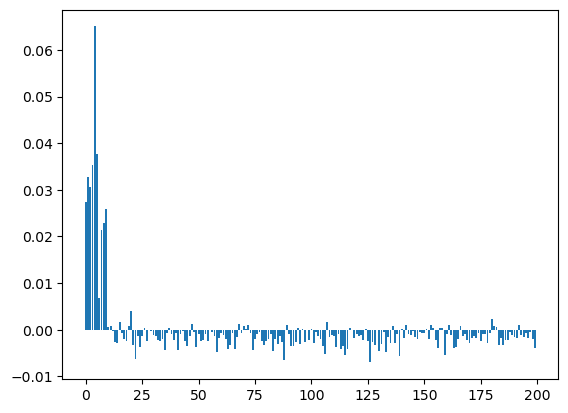

In [30]:
plt.bar(np.arange(200), res_mp)

In [31]:
if R_mc < 2:
    raise ValueError("R_mc must be at least 2 to estimate Monte Carlo uncertainty")
seeds_mp = np.random.default_rng(2027).choice(2**32, size=R_mc, replace=False)
results_mp = Parallel(n_jobs=2, backend='loky', verbose=10)(
    delayed(compute_mp_target)(s, N_mp, p_mp, B_mp, patch_n_mp, patch_m_mp, K_mp)
    for s in seeds_mp
)
Deltas_mp = np.stack([r[0] for r in results_mp])
n_eff_mc_mp = np.stack([r[1] for r in results_mp])
Delta_mp = Deltas_mp.mean(axis=0)
split_sd_mp = Deltas_mp.std(axis=0, ddof=1)
mc_se_mp = split_sd_mp / np.sqrt(len(Deltas_mp))
for j in range(p_mp):
    print(f'Feature {j+1}: target={Delta_mp[j]:.5f}, MC SE={mc_se_mp[j]:.5f}, '
          f'observed={res_mp[j]:.5f}, '
          f'observed percentile={100*np.mean(Deltas_mp[:,j] <= res_mp[j]):.1f}%, '
          f'minimum valid observations={n_eff_mc_mp[:,j].min()}/{N_mp}')

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:  4.2min
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:  8.1min
[Parallel(n_jobs=2)]: Done   9 tasks      | elapsed: 20.3min
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed: 29.0min
[Parallel(n_jobs=2)]: Done  21 tasks      | elapsed: 44.4min
[Parallel(n_jobs=2)]: Done  28 tasks      | elapsed: 53.7min
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed: 67.0min
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed: 79.6min
[Parallel(n_jobs=2)]: Done  57 tasks      | elapsed: 95.1min
[Parallel(n_jobs=2)]: Done  68 tasks      | elapsed: 110.6min
[Parallel(n_jobs=2)]: Done  81 tasks      | elapsed: 128.2min
[Parallel(n_jobs=2)]: Done  94 tasks      | elapsed: 147.3min
[Parallel(n_jobs=2)]: Done 109 tasks      | elapsed: 169.9min
[Parallel(n_jobs=2)]: Done 124 tasks      | elapsed: 193.7min
[Parallel(n_jobs=2)]: Done 141 tasks      | elapsed: 219.0min
[Par

Feature 1: target=0.02853, MC SE=0.00013, observed=0.02735, observed percentile=23.0%, minimum valid observations=500/500
Feature 2: target=0.03382, MC SE=0.00012, observed=0.03271, observed percentile=27.0%, minimum valid observations=500/500
Feature 3: target=0.03090, MC SE=0.00014, observed=0.03053, observed percentile=41.0%, minimum valid observations=500/500
Feature 4: target=0.03518, MC SE=0.00013, observed=0.03535, observed percentile=52.0%, minimum valid observations=500/500
Feature 5: target=0.06374, MC SE=0.00013, observed=0.06503, observed percentile=74.0%, minimum valid observations=500/500
Feature 6: target=0.03864, MC SE=0.00014, observed=0.03761, observed percentile=24.5%, minimum valid observations=500/500
Feature 7: target=0.00583, MC SE=0.00013, observed=0.00689, observed percentile=71.5%, minimum valid observations=500/500
Feature 8: target=0.02291, MC SE=0.00015, observed=0.02129, observed percentile=19.0%, minimum valid observations=500/500
Feature 9: target=0.0246

[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed: 337.4min finished


In [36]:
np.save('../data/cluster_locomp_mc.npy', Deltas_mp, allow_pickle=True)

<BarContainer object of 200 artists>

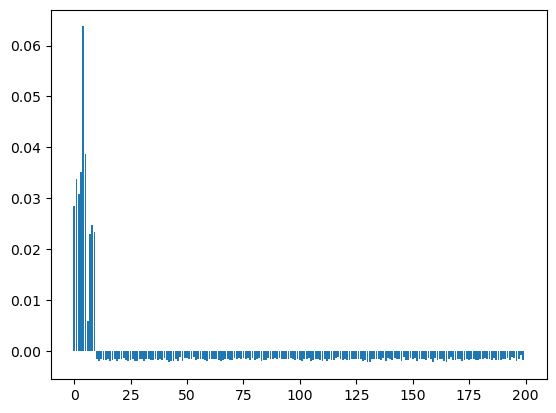

In [45]:
plt.bar(np.arange(200), np.mean(Deltas_mp, axis=0))

{'whiskers': [<matplotlib.lines.Line2D at 0x32107f160>,
 'caps': [<matplotlib.lines.Line2D at 0x32107f760>,
 'boxes': [<matplotlib.lines.Line2D at 0x32107ee60>,
 'medians': [<matplotlib.lines.Line2D at 0x32107fd60>,
 'fliers': [<matplotlib.lines.Line2D at 0x3210b40a0>,
 'means': []}

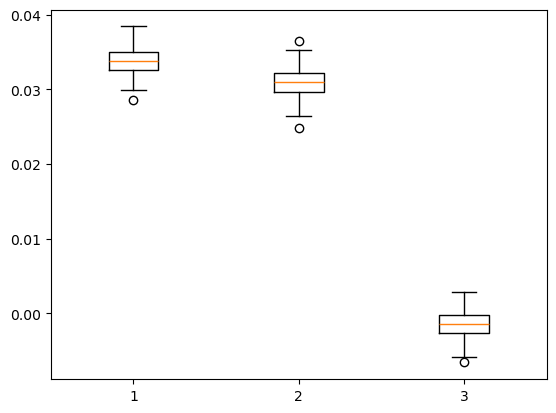

In [46]:
plt.boxplot([Deltas_mp[:,j] for j in p_plot])

In [56]:
mc_se_mp.shape

(200,)

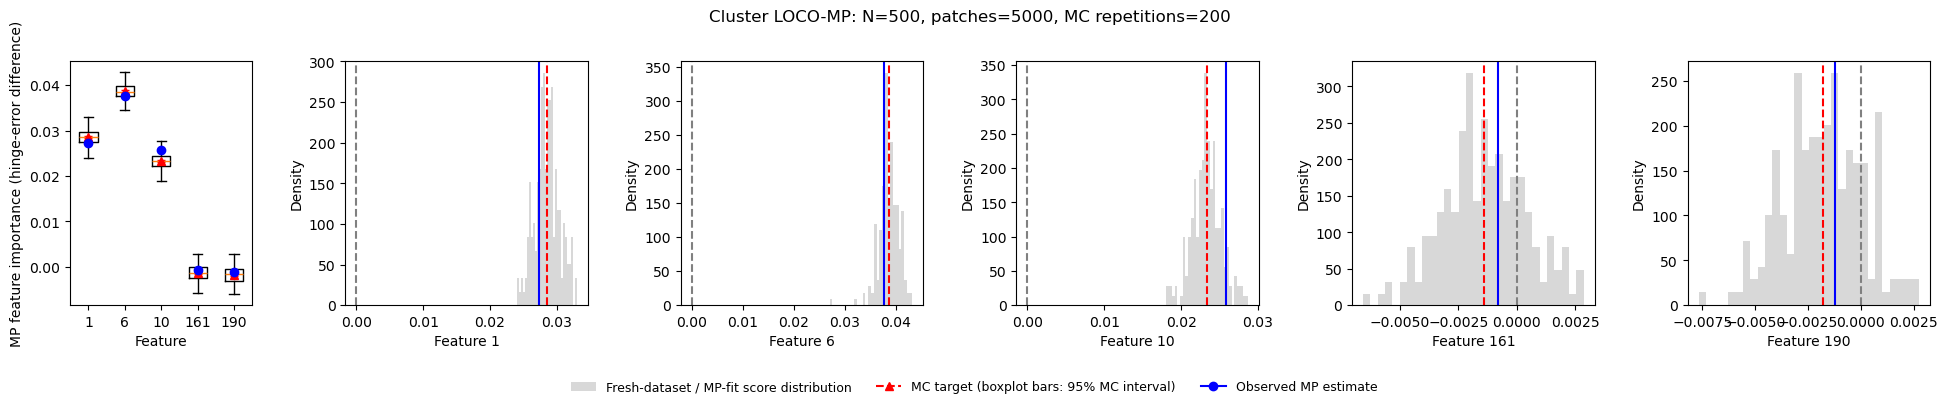

In [63]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
Delta_mp = np.mean(Deltas_mp, axis=0)
p_plot = [0, 5, 9, 160, 189]
p_mp = len(p_plot)
fig_mp, axes_mp = plt.subplots(1, p_mp+1, figsize=(4*(p_mp+1), 4),
                               gridspec_kw={'width_ratios': [1.5] + [2]*p_mp})
axes_mp[0].boxplot([Deltas_mp[:, j] for j in p_plot], tick_labels=[str(j+1) for j in p_plot],
                   showfliers=False)
axes_mp[0].errorbar(np.arange(1, p_mp+1), [Delta_mp[j] for j in p_plot], yerr=[1.96*mc_se_mp[j] for j in p_plot],
                    fmt='^', color='r', capsize=3)
axes_mp[0].scatter(np.arange(1, p_mp+1), [res_mp[j] for j in p_plot ], color='b', marker='o', zorder=4)
axes_mp[0].set(xlabel='Feature', ylabel='MP feature importance (hinge-error difference)')
for i, j in enumerate(p_plot):
    axes_mp[i+1].hist(Deltas_mp[:,j], bins=30, density=True, color='gray', alpha=0.3)
    axes_mp[i+1].axvline(Delta_mp[j], color='r', linestyle='--')
    axes_mp[i+1].axvline(0, color='gray', linestyle='--')
    axes_mp[i+1].axvline(res_mp[j], color='b')
    axes_mp[i+1].set(xlabel=f'Feature {j+1}', ylabel='Density')
fig_mp.suptitle(f'Cluster LOCO-MP: N={N_mp}, patches={B_mp}, MC repetitions={len(Deltas_mp)}')
fig_mp.legend(handles=[
    Patch(facecolor='gray', alpha=0.3, label='Fresh-dataset / MP-fit score distribution'),
    Line2D([], [], color='r', marker='^', linestyle='--', label='MC target (boxplot bars: 95% MC interval)'),
    Line2D([], [], color='b', marker='o', label='Observed MP estimate'),
], loc='lower center', ncol=3, frameon=False, fontsize=9)
fig_mp.subplots_adjust(bottom=0.24, wspace=0.4, top=0.85)
plt.show()

In [ ]:

axes_mp[0].boxplot([Deltas_mp[:, j] for j in p_plot], tick_labels=[str(j+1) for j in p_plot],
                   showfliers=False)
axes_mp[0].errorbar(np.arange(1, p_mp+1), [Delta_mp[j] for j in p_plot], yerr=[1.96*mc_se_mp[j] for j in p_plot],
                    fmt='^', color='r', capsize=3)
axes_mp[0].scatter(np.arange(1, p_mp+1), [res_mp[j] for j in p_plot ], color='b', marker='o', zorder=4)
axes_mp[0].set(xlabel='Feature', ylabel='MP feature importance (hinge-error difference)')